# ChessRender360 — Approach C: End-to-End Projective Spatial Transformer Network

End-to-end pipeline: ResNet-18 backbone, projective STN with custom pure-PyTorch differentiable warp, per-square classifier (optional cross-square attention), trained jointly with curriculum and decayed auxiliary corner loss.


## 0. Setup


In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os, subprocess, shutil, getpass

TOKEN_PATH = "/content/drive/MyDrive/Colab Notebooks/chess_cv_project/kaggle_token.txt"
with open(TOKEN_PATH) as f:
    KAGGLE_API_TOKEN = f.read().strip()

CHESSRENDER_ROOT = "/content/ChessRender360"
SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/chess_cv_project/ChessRender360"
os.makedirs(SAVE_DIR, exist_ok=True)

if not (os.path.isdir(os.path.join(CHESSRENDER_ROOT, "rgb")) and
        os.path.isdir(os.path.join(CHESSRENDER_ROOT, "annotations"))):
    subprocess.run(["pip", "install", "-q", "kaggle"], check=True)
    os.makedirs("/root/.kaggle", exist_ok=True)
    with open("/root/.kaggle/access_token", "w") as f:
        f.write(KAGGLE_API_TOKEN)
    os.chmod("/root/.kaggle/access_token", 0o600)
    os.environ["KAGGLE_API_TOKEN"] = KAGGLE_API_TOKEN

    os.makedirs("/content/_dl_tmp", exist_ok=True)
    subprocess.run(["kaggle", "datasets", "download", "-d", "mmkoya/chessrender360",
                    "-p", "/content/_dl_tmp", "--unzip"], check=True)

    os.makedirs(CHESSRENDER_ROOT, exist_ok=True)
    for sub in ("rgb", "annotations"):
        src = None
        for root, dirs, _ in os.walk("/content/_dl_tmp"):
            if sub in dirs:
                src = os.path.join(root, sub); break
        if src is None:
            raise RuntimeError(f"Could not locate '{sub}' inside the downloaded archive.")
        dst = os.path.join(CHESSRENDER_ROOT, sub)
        if not os.path.exists(dst):
            shutil.move(src, dst)
    shutil.rmtree("/content/_dl_tmp", ignore_errors=True)

print("rgb files:        ", len(os.listdir(os.path.join(CHESSRENDER_ROOT, "rgb"))))
print("annotation files: ", len(os.listdir(os.path.join(CHESSRENDER_ROOT, "annotations"))))

Mounted at /content/drive
rgb files:         10000
annotation files:  10000


In [2]:
import os
import glob
import json
import re
import math
import random
import time
import copy
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import models, transforms
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


In [3]:
import os
RGB_DIR = os.path.join(CHESSRENDER_ROOT, 'rgb')
ANN_DIR = os.path.join(CHESSRENDER_ROOT, 'annotations')
INPUT_SIZE = 256
WARP_SIZE = 256
PATCH_SIZE = WARP_SIZE // 8
SEED = 42
BATCH_SIZE = 8
NUM_EPOCHS = 25
LR = 0.0003
WEIGHT_DECAY = 0.0001
LAMBDA_CORNER_INIT = 1.0
LAMBDA_CORNER_END = 0.05
LAMBDA_CLS = 1.0
TRAIN_FRAC = 0.8
VAL_FRAC = 0.1
TEST_FRAC = 0.1
MAX_IMAGES = 1200
USE_CURRICULUM = True
CURRICULUM_WARMUP_EPOCHS = 5
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
print('CHESSRENDER_ROOT:', CHESSRENDER_ROOT)
print('SAVE_DIR        :', SAVE_DIR)


CHESSRENDER_ROOT: /content/ChessRender360
SAVE_DIR        : /content/drive/MyDrive/Colab Notebooks/chess_cv_project/ChessRender360


## 1. Dataset


In [4]:
CLASS_NAMES = ['Empty', 'Pawn_White', 'Pawn_Black', 'Knight_White', 'Knight_Black', 'Bishop_White', 'Bishop_Black', 'Rook_White', 'Rook_Black', 'Queen_White', 'Queen_Black', 'King_White', 'King_Black']
NUM_CLASSES = len(CLASS_NAMES)
NAME_TO_IDX = {n: i for i, n in enumerate(CLASS_NAMES)}
PIECE_TO_CLASS = {'white_pawn': 'Pawn_White', 'black_pawn': 'Pawn_Black', 'white_knight': 'Knight_White', 'black_knight': 'Knight_Black', 'white_bishop': 'Bishop_White', 'black_bishop': 'Bishop_Black', 'white_rook': 'Rook_White', 'black_rook': 'Rook_Black', 'white_queen': 'Queen_White', 'black_queen': 'Queen_Black', 'white_king': 'King_White', 'black_king': 'King_Black'}
PIECE_TO_FEN = {'Empty': None, 'Pawn_White': 'P', 'Pawn_Black': 'p', 'Knight_White': 'N', 'Knight_Black': 'n', 'Bishop_White': 'B', 'Bishop_Black': 'b', 'Rook_White': 'R', 'Rook_Black': 'r', 'Queen_White': 'Q', 'Queen_Black': 'q', 'King_White': 'K', 'King_Black': 'k'}


In [5]:
def discover_ids(root):
    import glob, re
    ann_files = glob.glob(os.path.join(root, 'annotations', '*.json'))
    ann_ids = set()
    for p in ann_files:
        m = re.search('annotation_(\\d+)\\.json$', os.path.basename(p))
        if m:
            ann_ids.add(int(m.group(1)))
    rgb_ids = set()
    for ext in ['jpg', 'jpeg', 'png', 'JPG', 'JPEG', 'PNG']:
        for p in glob.glob(os.path.join(root, 'rgb', f'rgb_*.{ext}')):
            m = re.search('rgb_(\\d+)\\.[^.]+$', os.path.basename(p))
            if m:
                rgb_ids.add(int(m.group(1)))
    return sorted(ann_ids & rgb_ids)

def get_rgb_path(idx):
    for ext in ['jpg', 'jpeg', 'png', 'JPG', 'JPEG', 'PNG']:
        p = os.path.join(RGB_DIR, f'rgb_{idx}.{ext}')
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f'no rgb for idx {idx}')

def load_annotation(idx):
    with open(os.path.join(ANN_DIR, f'annotation_{idx}.json'), 'r') as f:
        return json.load(f)

def get_corners_xy(ann):
    if 'board_corners' in ann and isinstance(ann['board_corners'], dict):
        c = ann['board_corners']
        try:
            tl = np.array(c['black_left'], dtype=np.float32)
            tr = np.array(c['black_right'], dtype=np.float32)
            br = np.array(c['white_right'], dtype=np.float32)
            bl = np.array(c['white_left'], dtype=np.float32)
            return np.stack([tl, tr, br, bl], axis=0)
        except KeyError:
            pass
    candidates = []
    for key in ['corners', 'corners_2d', 'chessboard_corners']:
        if key in ann:
            candidates = ann[key]
            break
    pts = np.array(candidates, dtype=np.float32).reshape(-1, 2)
    if pts.shape[0] != 4:
        raise ValueError(f'could not parse 4 corners; got shape {pts.shape}, keys={list(ann.keys())}')
    s = pts.sum(axis=1)
    d = np.diff(pts, axis=1).flatten()
    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(d)]
    bl = pts[np.argmax(d)]
    return np.stack([tl, tr, br, bl], axis=0).astype(np.float32)

def get_square_labels(ann):
    grid = np.zeros((8, 8), dtype=np.int64)
    pieces = ann.get('pieces', []) or ann.get('piece_positions', [])
    for p in pieces:
        pos = p.get('position')
        if isinstance(pos, dict) and 'row' in pos and ('column' in pos):
            r_white = int(pos['row'])
            col = int(pos['column'])
            row = 7 - r_white
        else:
            sq = p.get('square') or pos
            if not isinstance(sq, str) or len(sq) < 2:
                continue
            file_char = sq[0].lower()
            rank_char = sq[1]
            col = ord(file_char) - ord('a')
            row = 8 - int(rank_char)
        kind = p.get('piece_name') or p.get('type') or p.get('piece') or p.get('name')
        if not kind:
            continue
        kind = kind.lower().replace(' ', '_')
        cls_name = PIECE_TO_CLASS.get(kind)
        if cls_name is None:
            continue
        if 0 <= row < 8 and 0 <= col < 8:
            grid[row, col] = NAME_TO_IDX[cls_name]
    return grid

def estimate_difficulty(corners, img_w, img_h):
    edges = []
    for i in range(4):
        a = corners[i]
        b = corners[(i + 1) % 4]
        edges.append(np.linalg.norm(a - b))
    edges = np.array(edges)
    return float((edges.max() - edges.min()) / (edges.mean() + 1e-06))
ALL_IDS = discover_ids(CHESSRENDER_ROOT)
print(f'Discovered {len(ALL_IDS)} (rgb, annotation) pairs')
assert len(ALL_IDS) > 0, f'No matched (rgb, annotation) pairs under {CHESSRENDER_ROOT}. Check that RGB_DIR={RGB_DIR} and ANN_DIR={ANN_DIR} exist and contain files.'
n_ok = 0
failed_examples = []
for _idx in ALL_IDS[:20]:
    try:
        _ann = load_annotation(_idx)
        _ = get_corners_xy(_ann)
        _ = get_square_labels(_ann)
        n_ok += 1
    except Exception as _e:
        failed_examples.append((_idx, str(_e)[:120]))
print(f'Parser sanity check: {n_ok}/20 sampled annotations parsed OK.')
if failed_examples:
    print('Examples of failures:')
    for _idx, _msg in failed_examples[:3]:
        print(f'  id={_idx}: {_msg}')
    _sample = load_annotation(failed_examples[0][0])
    print(f'  Sample annotation keys: {list(_sample.keys())}')
    if 'board_corners' in _sample:
        print(f'  board_corners type: {type(_sample['board_corners']).__name__}, keys/length: {(list(_sample['board_corners'].keys()) if isinstance(_sample['board_corners'], dict) else len(_sample['board_corners']))}')
assert n_ok >= 15, 'Annotation parser failed on most samples; see messages above.'
if MAX_IMAGES is not None:
    ALL_IDS = ALL_IDS[:MAX_IMAGES]
random.Random(SEED).shuffle(ALL_IDS)
n_train = int(TRAIN_FRAC * len(ALL_IDS))
n_val = int(VAL_FRAC * len(ALL_IDS))
TRAIN_IDS = sorted(ALL_IDS[:n_train])
VAL_IDS = sorted(ALL_IDS[n_train:n_train + n_val])
TEST_IDS = sorted(ALL_IDS[n_train + n_val:])
print(f'Splits: train={len(TRAIN_IDS)}  val={len(VAL_IDS)}  test={len(TEST_IDS)}')


Discovered 10000 (rgb, annotation) pairs
Parser sanity check: 20/20 sampled annotations parsed OK.
Splits: train=960  val=120  test=120


## 2. PyTorch Dataset


In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class ChessSTNDataset(Dataset):

    def __init__(self, ids, input_size=INPUT_SIZE, augment=False, verbose=True):
        self.ids = list(ids)
        self.input_size = input_size
        self.augment = augment
        self._cache_difficulty(verbose=verbose)
        self.normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

    def _cache_difficulty(self, verbose=True):
        diffs = []
        keep = []
        n_drop_ann = 0
        n_drop_img = 0
        first_errors = []
        for idx in self.ids:
            try:
                ann = load_annotation(idx)
                corners = get_corners_xy(ann)
            except Exception as e:
                n_drop_ann += 1
                if len(first_errors) < 3:
                    first_errors.append((idx, 'ann', str(e)[:120]))
                continue
            try:
                img = cv2.imread(get_rgb_path(idx))
                if img is None:
                    n_drop_img += 1
                    continue
                h, w = img.shape[:2]
                d = estimate_difficulty(corners, w, h)
                diffs.append(d)
                keep.append(idx)
            except Exception as e:
                n_drop_img += 1
                if len(first_errors) < 3:
                    first_errors.append((idx, 'img', str(e)[:120]))
                continue
        self.ids = keep
        self.difficulty = np.array(diffs, dtype=np.float32)
        if verbose:
            print(f'  ChessSTNDataset: kept {len(keep)} / dropped ann={n_drop_ann} img={n_drop_img}')
            for idx, kind, msg in first_errors:
                print(f'    drop[{kind}] id={idx}: {msg}')

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        idx = self.ids[i]
        img_bgr = cv2.imread(get_rgb_path(idx))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h0, w0 = img_rgb.shape[:2]
        ann = load_annotation(idx)
        corners_px = get_corners_xy(ann)
        labels = get_square_labels(ann)
        img_r = cv2.resize(img_rgb, (self.input_size, self.input_size))
        sx = self.input_size / w0
        sy = self.input_size / h0
        corners_r = corners_px.copy()
        corners_r[:, 0] *= sx
        corners_r[:, 1] *= sy
        if self.augment and random.random() < 0.7:
            img_pil = Image.fromarray(img_r)
            jit = transforms.ColorJitter(0.25, 0.25, 0.25, 0.05)
            img_r = np.array(jit(img_pil))
        corners_norm = corners_r / float(self.input_size)
        img_t = torch.from_numpy(img_r.transpose(2, 0, 1)).float() / 255.0
        img_t = self.normalize(img_t)
        return {'image': img_t, 'corners_norm': torch.from_numpy(corners_norm).float(), 'labels': torch.from_numpy(labels).long(), 'idx': idx, 'difficulty': float(self.difficulty[i])}
print('Building train/val/test datasets...')
train_ds = ChessSTNDataset(TRAIN_IDS, augment=True)
val_ds = ChessSTNDataset(VAL_IDS, augment=False)
test_ds = ChessSTNDataset(TEST_IDS, augment=False)
print(f'After filtering: train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}')
assert len(train_ds) > 0, 'Training dataset is empty after filtering.'
assert len(val_ds) > 0, 'Validation dataset is empty after filtering.'
assert len(test_ds) > 0, 'Test dataset is empty after filtering.'


Building train/val/test datasets...
  ChessSTNDataset: kept 960 / dropped ann=0 img=0
  ChessSTNDataset: kept 120 / dropped ann=0 img=0
  ChessSTNDataset: kept 120 / dropped ann=0 img=0
After filtering: train=960 val=120 test=120


## 3. Differentiable Projective Warp


In [7]:
def solve_homography_dlt(src_pts: torch.Tensor, dst_pts: torch.Tensor) -> torch.Tensor:
    B = src_pts.shape[0]
    device = src_pts.device
    dtype = src_pts.dtype
    xs, ys = (src_pts[..., 0], src_pts[..., 1])
    xd, yd = (dst_pts[..., 0], dst_pts[..., 1])
    zero = torch.zeros_like(xs)
    one = torch.ones_like(xs)
    row1 = torch.stack([xs, ys, one, zero, zero, zero, -xs * xd, -ys * xd], dim=-1)
    row2 = torch.stack([zero, zero, zero, xs, ys, one, -xs * yd, -ys * yd], dim=-1)
    A = torch.cat([row1, row2], dim=1)
    b = torch.cat([xd, yd], dim=1).unsqueeze(-1)
    eye = torch.eye(8, device=device, dtype=dtype).unsqueeze(0) * 1e-06
    h_vec = torch.linalg.solve(A + eye, b).squeeze(-1)
    h_full = torch.cat([h_vec, torch.ones(B, 1, device=device, dtype=dtype)], dim=1)
    H = h_full.view(B, 3, 3)
    return H

def warp_perspective_torch(img: torch.Tensor, H: torch.Tensor, out_size: int) -> torch.Tensor:
    B, C, H_in, W_in = img.shape
    dtype = img.dtype
    device = img.device
    ys, xs = torch.meshgrid(torch.arange(out_size, device=device, dtype=dtype), torch.arange(out_size, device=device, dtype=dtype), indexing='ij')
    ones = torch.ones_like(xs)
    grid_out = torch.stack([xs, ys, ones], dim=0).reshape(3, -1)
    grid_out = grid_out.unsqueeze(0).expand(B, -1, -1)
    H_inv = torch.linalg.inv(H)
    src_h = torch.bmm(H_inv, grid_out)
    src_x = src_h[:, 0, :] / (src_h[:, 2, :] + 1e-08)
    src_y = src_h[:, 1, :] / (src_h[:, 2, :] + 1e-08)
    norm_x = 2.0 * src_x / (W_in - 1) - 1.0
    norm_y = 2.0 * src_y / (H_in - 1) - 1.0
    grid = torch.stack([norm_x, norm_y], dim=-1).reshape(B, out_size, out_size, 2)
    return F.grid_sample(img, grid, mode='bilinear', padding_mode='zeros', align_corners=True)

def _test_warp_identity():
    x = torch.randn(2, 3, 64, 64)
    src = torch.tensor([[[0.0, 0.0], [63.0, 0.0], [63.0, 63.0], [0.0, 63.0]]] * 2)
    dst = src.clone()
    H = solve_homography_dlt(src, dst)
    y = warp_perspective_torch(x, H, 64)
    err = (x - y).abs().mean().item()
    print(f'identity warp reconstruction error: {err:.5f} (should be ~0)')
_test_warp_identity()


identity warp reconstruction error: 0.00000 (should be ~0)


## 4. Model


In [8]:
class ProjectiveSTN(nn.Module):

    def __init__(self, in_channels: int, out_size: int=WARP_SIZE):
        super().__init__()
        self.out_size = out_size
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(in_channels, 128), nn.ReLU(inplace=True), nn.Linear(128, 8))
        nn.init.zeros_(self.head[-1].weight)
        nn.init.zeros_(self.head[-1].bias)

    def forward(self, feats: torch.Tensor, input_size: int) -> Tuple[torch.Tensor, torch.Tensor]:
        B = feats.shape[0]
        device = feats.device
        init = torch.tensor([[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0]], device=device).unsqueeze(0).expand(B, -1, -1)
        delta = self.head(feats).view(B, 4, 2) * 0.5
        corners_norm = init + delta
        src_px = corners_norm * float(input_size)
        S = float(self.out_size)
        dst_px = torch.tensor([[0.0, 0.0], [S - 1, 0.0], [S - 1, S - 1], [0.0, S - 1]], device=device).unsqueeze(0).expand(B, -1, -1)
        H = solve_homography_dlt(src_px, dst_px)
        return (corners_norm, H)

class AffineSTN(nn.Module):

    def __init__(self, in_channels: int, out_size: int=WARP_SIZE):
        super().__init__()
        self.out_size = out_size
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(in_channels, 128), nn.ReLU(inplace=True), nn.Linear(128, 6))
        nn.init.zeros_(self.head[-1].weight)
        self.head[-1].bias.data.copy_(torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float))

    def forward(self, feats: torch.Tensor, input_size: int):
        B = feats.shape[0]
        theta = self.head(feats).view(B, 2, 3)
        bottom = torch.tensor([[0.0, 0.0, 1.0]], device=feats.device).expand(B, 1, 3)
        H = torch.cat([theta, bottom], dim=1)
        S_out = float(self.out_size)
        S_in = float(input_size)
        T_out = torch.tensor([[2.0 / (S_out - 1), 0, -1.0], [0, 2.0 / (S_out - 1), -1.0], [0, 0, 1.0]], device=feats.device).unsqueeze(0).expand(B, -1, -1)
        T_in_inv = torch.tensor([[(S_in - 1) / 2.0, 0, (S_in - 1) / 2.0], [0, (S_in - 1) / 2.0, (S_in - 1) / 2.0], [0, 0, 1.0]], device=feats.device).unsqueeze(0).expand(B, -1, -1)
        H_pix = torch.bmm(T_in_inv, torch.bmm(H, T_out))
        H_fwd = torch.linalg.inv(H_pix)
        canon = torch.tensor([[0.0, 0.0, 1.0], [S_out - 1, 0.0, 1.0], [S_out - 1, S_out - 1, 1.0], [0.0, S_out - 1, 1.0]], device=feats.device).T.unsqueeze(0).expand(B, -1, -1)
        H_inv = torch.linalg.inv(H_fwd)
        src_h = torch.bmm(H_inv, canon)
        src_xy = src_h[:, :2, :] / (src_h[:, 2:3, :] + 1e-08)
        corners_norm = src_xy.transpose(1, 2) / float(input_size)
        return (corners_norm, H_fwd)


In [9]:
class SquareEncoder(nn.Module):

    def __init__(self, patch_size: int=PATCH_SIZE, dim: int=128):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2), nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.Conv2d(128, dim, 3, padding=1), nn.BatchNorm2d(dim), nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d(1), nn.Flatten())

    def forward(self, x):
        return self.net(x)

class CrossSquareAttention(nn.Module):

    def __init__(self, dim: int=128, nhead: int=4, num_layers: int=2):
        super().__init__()
        self.pos = nn.Parameter(torch.zeros(1, 64, dim))
        nn.init.trunc_normal_(self.pos, std=0.02)
        layer = nn.TransformerEncoderLayer(d_model=dim, nhead=nhead, dim_feedforward=dim * 2, dropout=0.1, batch_first=True, activation='gelu')
        self.enc = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, tokens):
        return self.enc(tokens + self.pos)

class ChessSTNModel(nn.Module):

    def __init__(self, stn_type: str='projective', use_attention: bool=False, input_size: int=INPUT_SIZE, warp_size: int=WARP_SIZE, patch_size: int=PATCH_SIZE, num_classes: int=NUM_CLASSES):
        super().__init__()
        self.input_size = input_size
        self.warp_size = warp_size
        self.patch_size = patch_size
        self.use_attention = use_attention
        self.stn_type = stn_type
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])
        feat_dim = 512
        if stn_type == 'projective':
            self.stn = ProjectiveSTN(in_channels=feat_dim, out_size=warp_size)
        elif stn_type == 'affine':
            self.stn = AffineSTN(in_channels=feat_dim, out_size=warp_size)
        else:
            raise ValueError(stn_type)
        self.encoder = SquareEncoder(patch_size=patch_size, dim=128)
        if use_attention:
            self.attn = CrossSquareAttention(dim=128, nhead=4, num_layers=2)
        self.classifier = nn.Linear(128, num_classes)

    def split_into_patches(self, warped):
        B, C, S, _ = warped.shape
        P = self.patch_size
        patches = warped.unfold(2, P, P).unfold(3, P, P)
        patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()
        return patches.view(B, 64, C, P, P)

    def forward(self, x: torch.Tensor):
        feats = self.backbone(x)
        corners_norm, H = self.stn(feats, self.input_size)
        warped = warp_perspective_torch(x, H, self.warp_size)
        patches = self.split_into_patches(warped)
        B, N, C, P, _ = patches.shape
        flat = patches.view(B * N, C, P, P)
        tok = self.encoder(flat).view(B, N, -1)
        if self.use_attention:
            tok = self.attn(tok)
        logits = self.classifier(tok)
        return {'logits': logits, 'corners_norm': corners_norm, 'warped': warped, 'H': H}
_m = ChessSTNModel(stn_type='projective', use_attention=False).to(device)
_x = torch.randn(2, 3, INPUT_SIZE, INPUT_SIZE, device=device)
_out = _m(_x)
print({k: v.shape if hasattr(v, 'shape') else v for k, v in _out.items()})
del _m, _x, _out


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 119MB/s]


{'logits': torch.Size([2, 64, 13]), 'corners_norm': torch.Size([2, 4, 2]), 'warped': torch.Size([2, 3, 256, 256]), 'H': torch.Size([2, 3, 3])}


## 5. Training


In [10]:
def make_loader(dataset, batch_size, shuffle, weighted=False):
    if weighted and len(dataset) > 0:
        weights = []
        for i in range(len(dataset)):
            ann = load_annotation(dataset.ids[i])
            n_pieces = len(ann.get('pieces', ann.get('piece_positions', [])))
            weights.append(1.0 + n_pieces / 32.0)
        sampler = WeightedRandomSampler(weights, num_samples=len(dataset), replacement=True)
        return DataLoader(dataset, batch_size=batch_size, sampler=sampler, num_workers=2)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=2)

def train_model(stn_type='projective', use_attention=False, use_curriculum=True, num_epochs=NUM_EPOCHS, tag='projective', verbose=True):
    model = ChessSTNModel(stn_type=stn_type, use_attention=use_attention).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs)
    ce = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_acc': [], 'val_piece_acc': [], 'val_corner_err': [], 'lambda_corner': []}
    best_val_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())
    diffs = train_ds.difficulty
    order = np.argsort(diffs)
    easy_half = [train_ds.ids[i] for i in order[:len(order) // 2]]
    if use_curriculum and len(easy_half) == 0:
        print('WARNING: curriculum subset is empty; disabling curriculum.')
        use_curriculum = False
    val_loader = make_loader(val_ds, BATCH_SIZE, shuffle=False)
    for ep in range(num_epochs):
        if use_curriculum and ep < CURRICULUM_WARMUP_EPOCHS:
            sub = ChessSTNDataset(easy_half, augment=True)
            train_loader = make_loader(sub, BATCH_SIZE, shuffle=True, weighted=True)
            phase = 'easy'
        else:
            train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True, weighted=True)
            phase = 'full'
        frac = ep / max(1, num_epochs - 1)
        lam_corner = LAMBDA_CORNER_INIT + frac * (LAMBDA_CORNER_END - LAMBDA_CORNER_INIT)
        model.train()
        t0 = time.time()
        running = 0.0
        n = 0
        for batch in train_loader:
            imgs = batch['image'].to(device)
            corners_gt = batch['corners_norm'].to(device)
            labels = batch['labels'].to(device).view(-1, 64)
            out = model(imgs)
            logits = out['logits']
            loss_cls = ce(logits.reshape(-1, NUM_CLASSES), labels.reshape(-1))
            loss_corner = F.mse_loss(out['corners_norm'], corners_gt)
            loss = LAMBDA_CLS * loss_cls + lam_corner * loss_corner
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            running += loss.item() * imgs.size(0)
            n += imgs.size(0)
        sched.step()
        train_loss = running / max(1, n)
        model.eval()
        correct_sq = 0
        total_sq = 0
        correct_pc = 0
        total_pc = 0
        corner_errs = []
        with torch.no_grad():
            for batch in val_loader:
                imgs = batch['image'].to(device)
                labels = batch['labels'].to(device).view(-1, 64)
                corners_gt = batch['corners_norm'].to(device)
                out = model(imgs)
                preds = out['logits'].argmax(dim=-1)
                correct_sq += (preds == labels).sum().item()
                total_sq += labels.numel()
                mask = labels != 0
                correct_pc += ((preds == labels) & mask).sum().item()
                total_pc += mask.sum().item()
                err_px = (out['corners_norm'] - corners_gt).norm(dim=-1) * INPUT_SIZE
                corner_errs.append(err_px.mean().item())
        val_acc = correct_sq / max(1, total_sq)
        val_piece = correct_pc / max(1, total_pc)
        val_corner = float(np.mean(corner_errs)) if corner_errs else float('nan')
        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['val_piece_acc'].append(val_piece)
        history['val_corner_err'].append(val_corner)
        history['lambda_corner'].append(lam_corner)
        if verbose:
            dt = time.time() - t0
            print(f'[{tag}] ep {ep:02d}  phase={phase}  loss={train_loss:.4f}  val_sq={val_acc:.4f}  val_piece={val_piece:.4f}  corner_err_px={val_corner:.2f}  lam_c={lam_corner:.3f}  ({dt:.1f}s)')
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            ckpt_path = os.path.join(SAVE_DIR, f'stn_{tag}_best.pth')
            torch.save({'model': best_state, 'history': history, 'config': {'stn_type': stn_type, 'use_attention': use_attention, 'use_curriculum': use_curriculum}}, ckpt_path)
    model.load_state_dict(best_state)
    return (model, history, best_val_acc)


### 5.1 Train main model


In [11]:
main_model, main_hist, main_best = train_model(stn_type='projective', use_attention=False, use_curriculum=True, num_epochs=NUM_EPOCHS, tag='projective_curriculum')
print(f'Main model best val-square-acc: {main_best:.4f}')


  ChessSTNDataset: kept 480 / dropped ann=0 img=0
[projective_curriculum] ep 00  phase=easy  loss=2.1412  val_sq=0.6275  val_piece=0.0000  corner_err_px=96.95  lam_c=1.000  (34.8s)
  ChessSTNDataset: kept 480 / dropped ann=0 img=0
[projective_curriculum] ep 01  phase=easy  loss=1.6947  val_sq=0.6275  val_piece=0.0000  corner_err_px=97.51  lam_c=0.960  (35.0s)
  ChessSTNDataset: kept 480 / dropped ann=0 img=0
[projective_curriculum] ep 02  phase=easy  loss=1.5891  val_sq=0.6270  val_piece=0.0000  corner_err_px=93.42  lam_c=0.921  (34.7s)
  ChessSTNDataset: kept 480 / dropped ann=0 img=0
[projective_curriculum] ep 03  phase=easy  loss=1.5256  val_sq=0.6275  val_piece=0.0000  corner_err_px=85.85  lam_c=0.881  (32.7s)
  ChessSTNDataset: kept 480 / dropped ann=0 img=0
[projective_curriculum] ep 04  phase=easy  loss=1.5109  val_sq=0.6273  val_piece=0.0007  corner_err_px=297.45  lam_c=0.842  (33.2s)
[projective_curriculum] ep 05  phase=full  loss=1.4611  val_sq=0.6272  val_piece=0.0000  corne

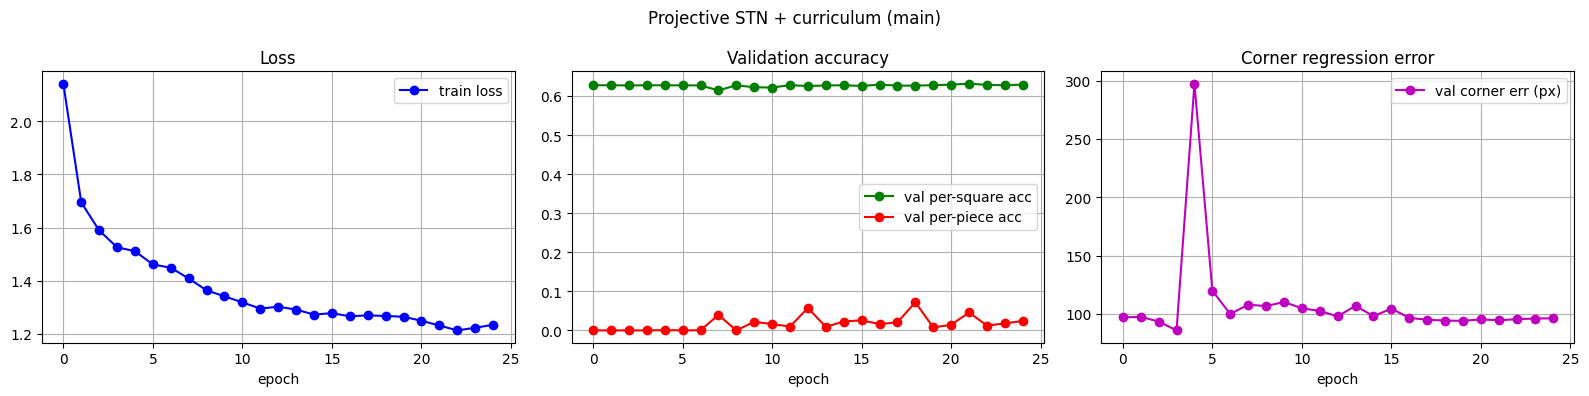

In [12]:
def plot_history(hist, title='Training history'):
    epochs = range(len(hist['train_loss']))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(epochs, hist['train_loss'], 'b-o', label='train loss')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('epoch')
    axes[0].grid(True)
    axes[0].legend()
    axes[1].plot(epochs, hist['val_acc'], 'g-o', label='val per-square acc')
    axes[1].plot(epochs, hist['val_piece_acc'], 'r-o', label='val per-piece acc')
    axes[1].set_title('Validation accuracy')
    axes[1].set_xlabel('epoch')
    axes[1].grid(True)
    axes[1].legend()
    axes[2].plot(epochs, hist['val_corner_err'], 'm-o', label='val corner err (px)')
    axes[2].set_title('Corner regression error')
    axes[2].set_xlabel('epoch')
    axes[2].grid(True)
    axes[2].legend()
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
plot_history(main_hist, 'Projective STN + curriculum (main)')


## 6. Evaluation


In [13]:
def board_to_fen(board_grid):
    rows = []
    for r in range(8):
        row = ''
        empty = 0
        for c in range(8):
            cls_idx = int(board_grid[r, c])
            cls_name = CLASS_NAMES[cls_idx]
            ch = PIECE_TO_FEN[cls_name]
            if ch is None:
                empty += 1
            else:
                if empty > 0:
                    row += str(empty)
                    empty = 0
                row += ch
        if empty > 0:
            row += str(empty)
        rows.append(row)
    return '/'.join(rows)

def quad_iou(quad_a, quad_b):
    poly_a = np.round(quad_a).astype(np.int32)
    poly_b = np.round(quad_b).astype(np.int32)
    h = max(poly_a[:, 1].max(), poly_b[:, 1].max()) + 5
    w = max(poly_a[:, 0].max(), poly_b[:, 0].max()) + 5
    h = max(h, 5)
    w = max(w, 5)
    ma = np.zeros((h, w), dtype=np.uint8)
    cv2.fillConvexPoly(ma, poly_a, 1)
    mb = np.zeros((h, w), dtype=np.uint8)
    cv2.fillConvexPoly(mb, poly_b, 1)
    inter = (ma & mb).sum()
    union = (ma | mb).sum()
    return float(inter) / float(union + 1e-08)

def evaluate_full(model, dataset, name='model'):
    model.eval()
    loader = make_loader(dataset, BATCH_SIZE, shuffle=False)
    sq_correct = 0
    sq_total = 0
    pc_correct = 0
    pc_total = 0
    occ_correct = 0
    occ_total = 0
    full_correct = 0
    full_total = 0
    fen_correct = 0
    corner_errs = []
    ious = []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f'eval {name}'):
            imgs = batch['image'].to(device)
            labels = batch['labels'].to(device)
            corners_gt = batch['corners_norm'].to(device)
            out = model(imgs)
            preds = out['logits'].argmax(dim=-1).view(-1, 8, 8)
            sq_correct += (preds == labels).sum().item()
            sq_total += labels.numel()
            mask_pc = labels != 0
            pc_correct += ((preds == labels) & mask_pc).sum().item()
            pc_total += mask_pc.sum().item()
            occ_pred = preds != 0
            occ_true = labels != 0
            occ_correct += (occ_pred == occ_true).sum().item()
            occ_total += labels.numel()
            B = labels.shape[0]
            for b in range(B):
                eq = bool((preds[b] == labels[b]).all().item())
                full_correct += int(eq)
                full_total += 1
                fen_p = board_to_fen(preds[b].cpu().numpy())
                fen_t = board_to_fen(labels[b].cpu().numpy())
                fen_correct += int(fen_p == fen_t)
            err_px = (out['corners_norm'] - corners_gt).norm(dim=-1) * INPUT_SIZE
            corner_errs.append(err_px.mean().item())
            cn_p = out['corners_norm'].cpu().numpy() * INPUT_SIZE
            cn_t = corners_gt.cpu().numpy() * INPUT_SIZE
            for b in range(B):
                ious.append(quad_iou(cn_p[b], cn_t[b]))
    metrics = {'name': name, 'per_square_acc': sq_correct / max(1, sq_total), 'per_piece_acc': pc_correct / max(1, pc_total), 'occupancy_acc': occ_correct / max(1, occ_total), 'full_board_acc': full_correct / max(1, full_total), 'fen_exact_match': fen_correct / max(1, full_total), 'corner_err_px': float(np.mean(corner_errs)) if corner_errs else float('nan'), 'rectification_iou': float(np.mean(ious)) if ious else float('nan'), 'n_images': full_total}
    return metrics
main_metrics = evaluate_full(main_model, test_ds, name='projective+curriculum')
for k, v in main_metrics.items():
    print(f'  {k}: {v}')


eval projective+curriculum:   0%|          | 0/15 [00:00<?, ?it/s]

  name: projective+curriculum
  per_square_acc: 0.6430989583333333
  per_piece_acc: 0.05041411595246669
  occupancy_acc: 0.6459635416666667
  full_board_acc: 0.0
  fen_exact_match: 0.0
  corner_err_px: 93.60905049641927
  rectification_iou: 0.34187635212489614
  n_images: 120


## 7. Visualization


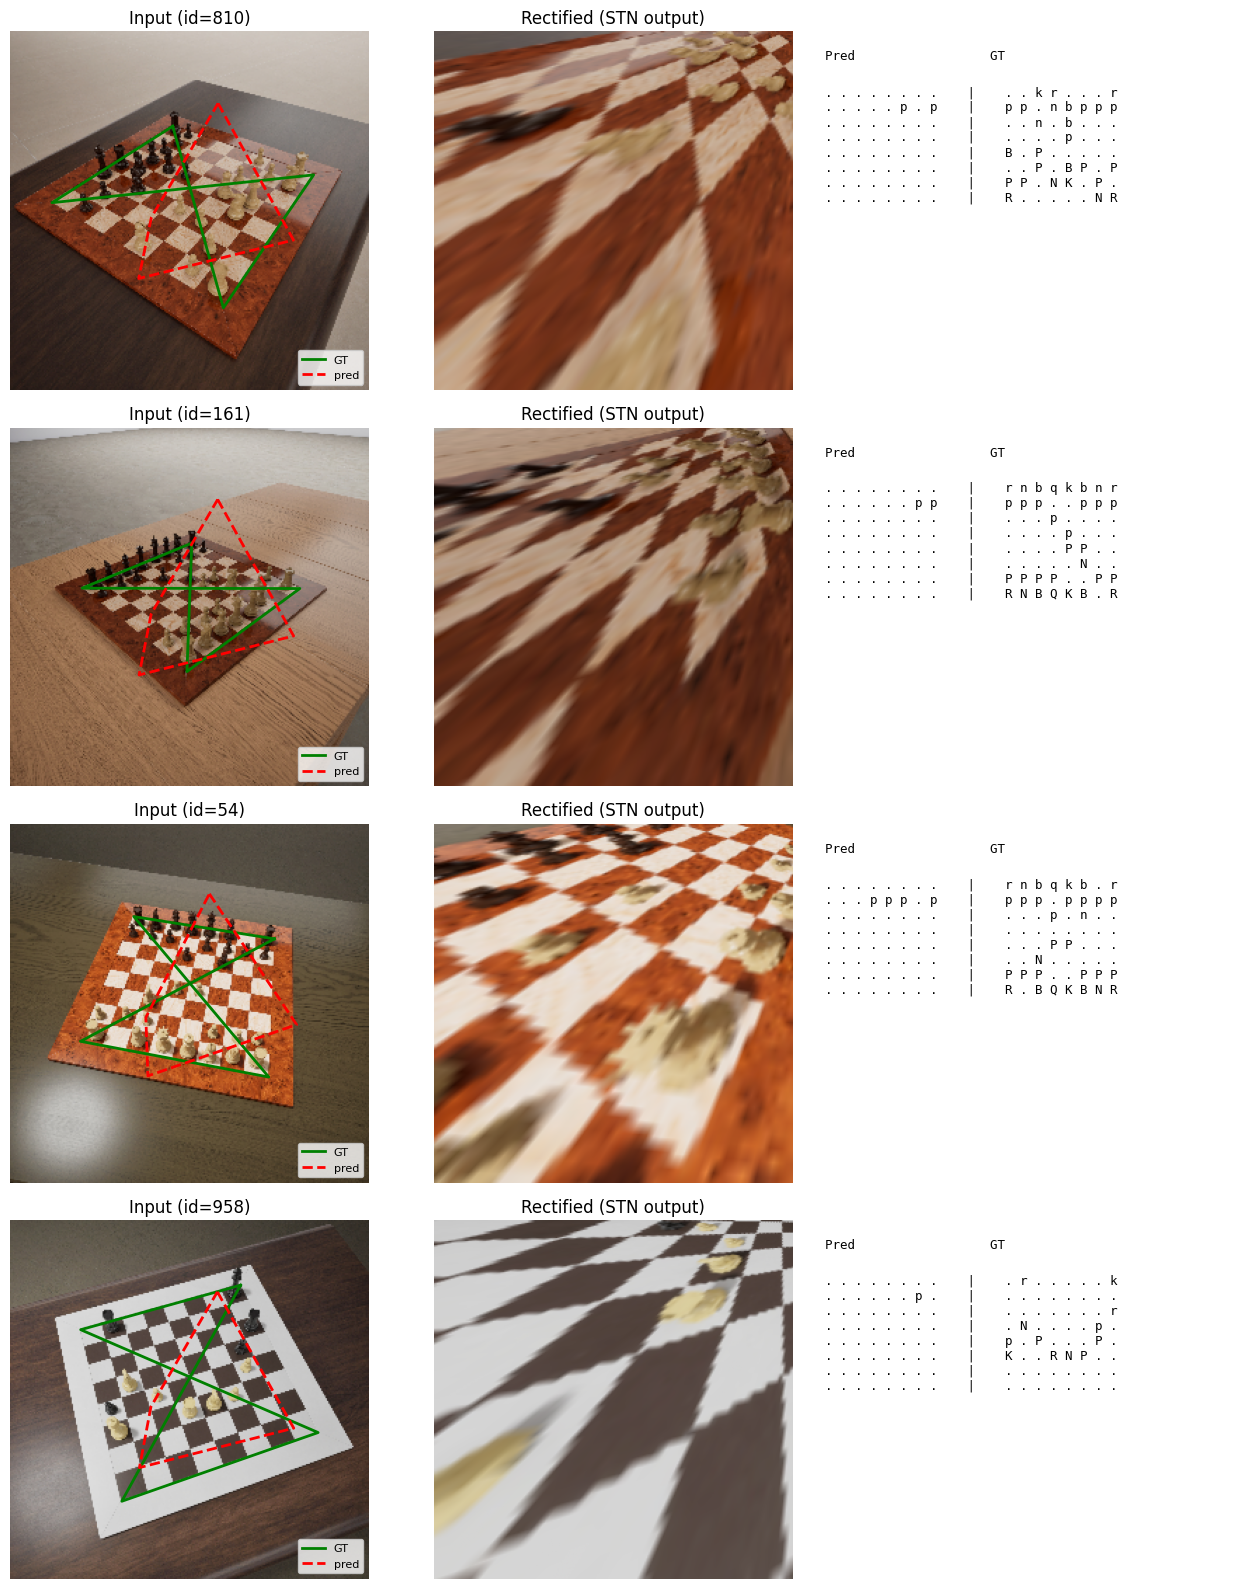

In [14]:
def denorm(t):
    mean = torch.tensor(IMAGENET_MEAN, device=t.device).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=t.device).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

def visualize_predictions(model, dataset, n=4):
    model.eval()
    idxs = random.sample(range(len(dataset)), min(n, len(dataset)))
    fig, axes = plt.subplots(n, 3, figsize=(13, 4 * n))
    if n == 1:
        axes = axes[None, :]
    with torch.no_grad():
        for row, i in enumerate(idxs):
            sample = dataset[i]
            img = sample['image'].unsqueeze(0).to(device)
            out = model(img)
            img_show = denorm(img[0]).cpu().permute(1, 2, 0).numpy()
            warped_show = denorm(out['warped'][0]).cpu().permute(1, 2, 0).numpy()
            axes[row, 0].imshow(img_show)
            cn_p = out['corners_norm'][0].cpu().numpy() * INPUT_SIZE
            cn_t = sample['corners_norm'].numpy() * INPUT_SIZE
            quad_p = np.concatenate([cn_p, cn_p[:1]], axis=0)
            quad_t = np.concatenate([cn_t, cn_t[:1]], axis=0)
            axes[row, 0].plot(quad_t[:, 0], quad_t[:, 1], 'g-', lw=2, label='GT')
            axes[row, 0].plot(quad_p[:, 0], quad_p[:, 1], 'r--', lw=2, label='pred')
            axes[row, 0].set_title(f'Input (id={sample['idx']})')
            axes[row, 0].legend(loc='lower right', fontsize=8)
            axes[row, 0].axis('off')
            axes[row, 1].imshow(warped_show)
            axes[row, 1].set_title('Rectified (STN output)')
            axes[row, 1].axis('off')
            preds = out['logits'][0].argmax(dim=-1).view(8, 8).cpu().numpy()
            true = sample['labels'].numpy()
            text = ''
            short = {'Empty': '.', 'Pawn_White': 'P', 'Pawn_Black': 'p', 'Knight_White': 'N', 'Knight_Black': 'n', 'Bishop_White': 'B', 'Bishop_Black': 'b', 'Rook_White': 'R', 'Rook_Black': 'r', 'Queen_White': 'Q', 'Queen_Black': 'q', 'King_White': 'K', 'King_Black': 'k'}
            for r in range(8):
                line_p = ' '.join((short[CLASS_NAMES[preds[r, c]]] for c in range(8)))
                line_t = ' '.join((short[CLASS_NAMES[true[r, c]]] for c in range(8)))
                text += f'{line_p}    |    {line_t}\n'
            axes[row, 2].text(0.0, 0.95, 'Pred                  GT', family='monospace', fontsize=9, transform=axes[row, 2].transAxes, va='top')
            axes[row, 2].text(0.0, 0.85, text, family='monospace', fontsize=9, transform=axes[row, 2].transAxes, va='top')
            axes[row, 2].axis('off')
    plt.tight_layout()
    plt.show()
visualize_predictions(main_model, test_ds, n=4)


## 8. Ablations


In [15]:
ABLATION_EPOCHS = max(10, NUM_EPOCHS // 2)
ablation_runs = {}
print('\n--- Ablation: Affine STN ---')
m_aff, h_aff, _ = train_model(stn_type='affine', use_attention=False, use_curriculum=False, num_epochs=ABLATION_EPOCHS, tag='affine_only')
ablation_runs['affine_only'] = evaluate_full(m_aff, test_ds, name='affine_only')
del m_aff
torch.cuda.empty_cache()
print('\n--- Ablation: Projective STN, no curriculum ---')
m_nc, h_nc, _ = train_model(stn_type='projective', use_attention=False, use_curriculum=False, num_epochs=ABLATION_EPOCHS, tag='projective_no_curriculum')
ablation_runs['projective_no_curriculum'] = evaluate_full(m_nc, test_ds, name='projective_no_curriculum')
del m_nc
torch.cuda.empty_cache()
print('\n--- Ablation: Projective STN + attention ---')
m_at, h_at, _ = train_model(stn_type='projective', use_attention=True, use_curriculum=True, num_epochs=ABLATION_EPOCHS, tag='projective_attention')
ablation_runs['projective_attention'] = evaluate_full(m_at, test_ds, name='projective_attention')
del m_at
torch.cuda.empty_cache()
ablation_runs['projective_curriculum (main)'] = main_metrics
print('\n========== ABLATION COMPARISON ==========')
header = ['model', 'sq_acc', 'piece_acc', 'occ_acc', 'full_acc', 'FEN', 'corner_err_px', 'rect_IoU']
print('{:<35s} {:>7s} {:>9s} {:>7s} {:>8s} {:>5s} {:>13s} {:>8s}'.format(*header))
for name, m in ablation_runs.items():
    print('{:<35s} {:7.4f} {:9.4f} {:7.4f} {:8.4f} {:5.4f} {:13.2f} {:8.4f}'.format(name, m['per_square_acc'], m['per_piece_acc'], m['occupancy_acc'], m['full_board_acc'], m['fen_exact_match'], m['corner_err_px'], m['rectification_iou']))



--- Ablation: Affine STN ---
[affine_only] ep 00  phase=full  loss=1.8542  val_sq=0.6275  val_piece=0.0000  corner_err_px=92.14  lam_c=1.000  (57.7s)
[affine_only] ep 01  phase=full  loss=1.5495  val_sq=0.6275  val_piece=0.0000  corner_err_px=88.30  lam_c=0.914  (57.5s)
[affine_only] ep 02  phase=full  loss=1.5371  val_sq=0.6275  val_piece=0.0000  corner_err_px=90.24  lam_c=0.827  (57.2s)
[affine_only] ep 03  phase=full  loss=1.4859  val_sq=0.6273  val_piece=0.0007  corner_err_px=137.31  lam_c=0.741  (57.8s)
[affine_only] ep 04  phase=full  loss=1.4309  val_sq=0.6275  val_piece=0.0000  corner_err_px=136.70  lam_c=0.655  (57.9s)
[affine_only] ep 05  phase=full  loss=1.3818  val_sq=0.6275  val_piece=0.0000  corner_err_px=163.96  lam_c=0.568  (56.7s)
[affine_only] ep 06  phase=full  loss=1.3693  val_sq=0.6275  val_piece=0.0000  corner_err_px=139.17  lam_c=0.482  (57.7s)
[affine_only] ep 07  phase=full  loss=1.3324  val_sq=0.6275  val_piece=0.0000  corner_err_px=148.65  lam_c=0.395  (57.7

eval affine_only:   0%|          | 0/15 [00:00<?, ?it/s]


--- Ablation: Projective STN, no curriculum ---
[projective_no_curriculum] ep 00  phase=full  loss=1.9542  val_sq=0.6263  val_piece=0.0000  corner_err_px=112.21  lam_c=1.000  (57.7s)
[projective_no_curriculum] ep 01  phase=full  loss=1.5537  val_sq=0.6275  val_piece=0.0000  corner_err_px=161.48  lam_c=0.914  (57.9s)
[projective_no_curriculum] ep 02  phase=full  loss=1.4553  val_sq=0.6264  val_piece=0.0049  corner_err_px=93.56  lam_c=0.827  (58.8s)
[projective_no_curriculum] ep 03  phase=full  loss=1.4394  val_sq=0.6267  val_piece=0.0003  corner_err_px=101.40  lam_c=0.741  (56.5s)
[projective_no_curriculum] ep 04  phase=full  loss=1.4514  val_sq=0.6275  val_piece=0.0000  corner_err_px=125.23  lam_c=0.655  (56.7s)
[projective_no_curriculum] ep 05  phase=full  loss=1.3799  val_sq=0.6279  val_piece=0.0017  corner_err_px=106.54  lam_c=0.568  (56.7s)
[projective_no_curriculum] ep 06  phase=full  loss=1.3201  val_sq=0.6262  val_piece=0.0056  corner_err_px=106.36  lam_c=0.482  (58.4s)
[projec

eval projective_no_curriculum:   0%|          | 0/15 [00:00<?, ?it/s]


--- Ablation: Projective STN + attention ---
  ChessSTNDataset: kept 480 / dropped ann=0 img=0
[projective_attention] ep 00  phase=easy  loss=1.6925  val_sq=0.6275  val_piece=0.0000  corner_err_px=119.93  lam_c=1.000  (31.6s)
  ChessSTNDataset: kept 480 / dropped ann=0 img=0
[projective_attention] ep 01  phase=easy  loss=1.5487  val_sq=0.6275  val_piece=0.0000  corner_err_px=112.72  lam_c=0.914  (31.5s)
  ChessSTNDataset: kept 480 / dropped ann=0 img=0
[projective_attention] ep 02  phase=easy  loss=1.3935  val_sq=0.6525  val_piece=0.2803  corner_err_px=363.29  lam_c=0.827  (31.3s)
  ChessSTNDataset: kept 480 / dropped ann=0 img=0
[projective_attention] ep 03  phase=easy  loss=1.1993  val_sq=0.6639  val_piece=0.3009  corner_err_px=127.55  lam_c=0.741  (31.6s)
  ChessSTNDataset: kept 480 / dropped ann=0 img=0
[projective_attention] ep 04  phase=easy  loss=1.1109  val_sq=0.6568  val_piece=0.2045  corner_err_px=123.00  lam_c=0.655  (31.6s)
[projective_attention] ep 05  phase=full  loss=1.

eval projective_attention:   0%|          | 0/15 [00:00<?, ?it/s]


========== ABLATION COMPARISON ==========
model                                sq_acc piece_acc occ_acc full_acc   FEN corner_err_px rect_IoU
affine_only                          0.6384    0.0000  0.6384   0.0000 0.0000         92.42   0.1565
projective_no_curriculum             0.6380    0.0018  0.6382   0.0000 0.0000        106.54   0.3259
projective_attention                 0.6654    0.2920  0.6760   0.0000 0.0000         97.37   0.2241
projective_curriculum (main)         0.6431    0.0504  0.6460   0.0000 0.0000         93.61   0.3419


In [16]:
with open(os.path.join(SAVE_DIR, 'stn_ablation_results.json'), 'w') as f:
    json.dump({k: {kk: vv for kk, vv in v.items() if kk != 'name'} for k, v in ablation_runs.items()}, f, indent=2)
print('Saved:', os.path.join(SAVE_DIR, 'stn_ablation_results.json'))


Saved: /content/drive/MyDrive/Colab Notebooks/chess_cv_project/ChessRender360/stn_ablation_results.json
